### Anomaly 1 — Duplicate customer-months (Customer Flight Activity)
- What: 3,871 rows shared a (Loyalty Number, Year, Month) key, violating the
  intended one-row-per-customer-per-month grain.
- Evidence: duplicated(subset=keys).sum() = 3,871; full-row dups = 1,922,
  so ~1,949 were conflicting (same key, different values).
- Decision: dropped exact-copy rows, then summed additive columns per
  customer-month. Rows went 392,936 → 389,065.
- Why: the columns (flights, distance, points) are additive monthly totals;
  conflicting rows are treated as partial-month records. Assumption documented.


### Anomaly 2 — Missing values (Customer Loyalty History)
- What: Salary missing for 4,238 rows; Cancellation Year and Cancellation
  Month each missing for 14,670 rows.
- Evidence: isnull().sum(); a cross-tab of missing-salary rows against
  Education showed 100% of them are in the "College" group.
- Decision:
  - Salary: do NOT impute with 0. Defer handling to the feature-engineering
    stage. (All College records lack salary, so there's no within-group data
    to impute from — any fill borrows from other education groups.)
  - Cancellation: NOT a data error. A missing cancellation date means the
    customer never cancelled (still active). 2,067 customers cancelled,
    14,670 remain active. Kept as-is; this directly feeds the churn definition.
- Why: missingness here is informative (cancellation) and systematic
  (salary tied to education), so naive imputation or row-dropping would
  distort the data.

### Anomaly 3 — Negative salaries (Customer Loyalty History)
- What: 20 rows had negative Salary values (impossible).
- Evidence: describe() min = -58,486; 20 rows < 0.
- Decision: took absolute value. Verified flipped values (9k–58k) fall in a
  plausible salary range, supporting the sign-error assumption.
- Why: negatives are data-entry sign flips; magnitude is the true salary.


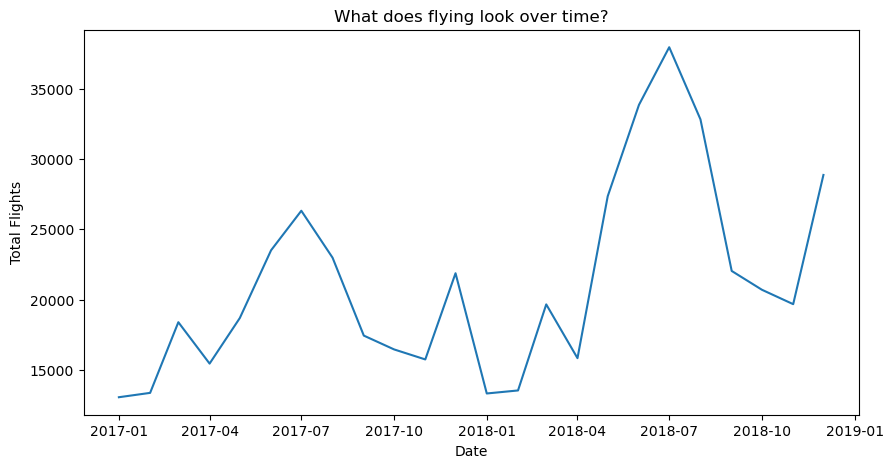

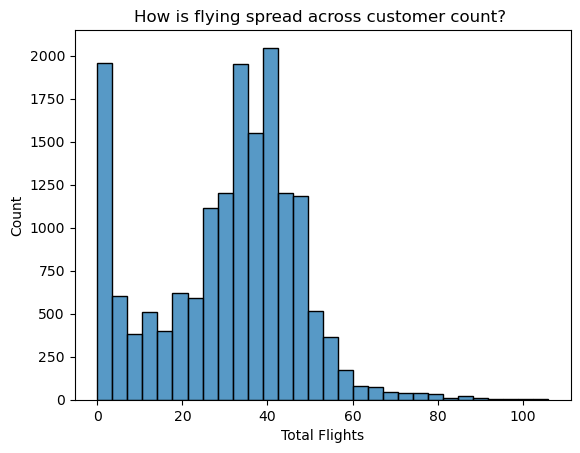

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
clh = pd.read_csv('Customer_Loyalty_History.csv')
cfa = pd.read_csv('Customer_flight_Activity.csv')
cal = pd.read_csv('Calendar.csv')
aldd = pd.read_csv('Airline_loyalty_Data_Dictionary.csv')

# "Flight Activity cleaning:
# - Grain should be one row per customer-month, but 3,871 (Loyalty Number, Year, Month) combinations were duplicated.
# - Of those, 1,922 were exact copies; the remaining ~1,949 were conflicting (same key, different values).
# - Fix: dropped exact copies first, then summed additive columns (flights, distance, points) per customer-month.
# - Assumption: conflicting rows are partial-month records, so the additive columns are summed.
# Result: 392,936 -> 389,065 rows, grain restored (0 remaining key duplicates)."
cfa_cleaned = cfa.copy()
cfa_cleaned = cfa_cleaned.drop_duplicates()
cfa_cleaned = cfa_cleaned.groupby(['Loyalty Number' ,'Year' , 'Month'] , as_index = False).sum()

# "Loyalty History cleaning:
# Salary: 20 negative values were sign-entry errors -> took absolute value (flipped values 9k-58k are plausible salaries).
# Salary: 4,238 missing, ALL in the 'College' group -> NOT filled with 0; deferred to feature stage (no within-College data to impute from).
# Cancellation Year/Month: 14,670 missing = ACTIVE members (never cancelled); only 2,067 cancelled. Kept as-is (feeds churn definition).
# Country: constant value 'Canada' -> dropped (zero information).
# Result: 16,737 rows x 15 columns. Consistency check passed (no cancellation dated before enrollment)."
clh_cleaned = clh.copy()
clh_cleaned['Salary'] = clh_cleaned['Salary'].abs()
clh_cleaned = clh_cleaned.drop('Country' , axis = 1)


#plot 1
monthly = cfa_cleaned.groupby(['Year', 'Month'], as_index=False)['Total Flights'].sum()
monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].rename(columns={'Year': 'year', 'Month': 'month'}).assign(day=1))
plt.figure(figsize = (10,5))
plt.title("What does flying look over time?")
sns.lineplot(data=monthly, x='Date', y='Total Flights')
plt.show()

#plot 2
customer_wise = cfa_cleaned.groupby('Loyalty Number' , as_index = False)['Total Flights'].sum()
sns.histplot(data = customer_wise , x = 'Total Flights' , bins = 30)
plt.title("How is flying spread across customer count? ")
plt.show()


### Churn definiton
 - Population: customers active in 2017 (the 12,439 — never-engaged are out of scope).
 - Label: a customer is churned if, in 2018, they had no flights in the second half of the year (Jul–Dec)
 - OR they formally cancelled. That's 1,011 churners, 8.1%.

In [2]:
# active in 2017
flights_2017 = cfa_cleaned[cfa_cleaned["Year"] == 2017]
f17 = flights_2017.groupby("Loyalty Number")["Total Flights"].sum()
active_2017 = f17[f17 > 0]

# no flights in H2 2018 (Jul–Dec)
flights_2018 = cfa_cleaned[cfa_cleaned["Year"] == 2018]
f18 = flights_2018[flights_2018["Month"] >= 7].groupby("Loyalty Number")["Total Flights"].sum()
inactive_HF_2018 = f18[f18 == 0]

# cancelled in 2018  
cancelled_cust = clh_cleaned[clh_cleaned["Cancellation Year"] == 2018]

# combine: churned = active_2017 AND (no H2 flights OR cancelled in 2018)
churned_ids = set(active_2017.index) & (set(inactive_HF_2018.index) | set(cancelled_cust["Loyalty Number"]))

# one row per active-2017 customer (your modeling population)
customers = pd.DataFrame(index=active_2017.index)

# churn label: 1 if this customer is in churned_ids, else 0
customers["churned"] = customers.index.isin(churned_ids).astype(int)

print(customers["churned"].sum())          # 1011
print(round(customers["churned"].mean()*100, 1), "%")   # 8.1%
customers.describe()

1011
8.1 %


,churned
count,12439.000000
mean,0.081277
std,0.273270
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [3]:
#feature 1A
customers["flights_2017"] = active_2017

# feature 2A
active = cfa_cleaned[(cfa_cleaned['Year'] == 2017) & (cfa_cleaned['Total Flights'] > 0)]
active_months = active.groupby('Loyalty Number')['Month'].count()
customers['active_months_2017'] = active_months.reindex(customers.index).fillna(0)

# feature 3A
last_active_month_2017 = active.groupby('Loyalty Number')['Month'].max()
customers['last_active_month_2017'] = last_active_month_2017.reindex(customers.index).fillna(0)

# feature 4A
h2 = active[active['Month'] > 6].groupby('Loyalty Number')['Total Flights'].sum()
h1 = active[active['Month'] <= 6].groupby('Loyalty Number')['Total Flights'].sum()
customers['trend_2017'] = (h2.reindex(customers.index).fillna(0)
                           - h1.reindex(customers.index).fillna(0))
# feature 5A
total_distance_2017 = active.groupby('Loyalty Number')['Distance'].sum()
customers['total_distance_2017'] = total_distance_2017.reindex(customers.index).fillna(0)

# feature 6A
points_accumulated_2017 = active.groupby('Loyalty Number')['Points Accumulated'].sum()
customers['points_accumulated_2017'] = points_accumulated_2017.reindex(customers.index).fillna(0)

# Ingridient for feature 7A
points_redeemed_2017 = active.groupby('Loyalty Number')['Points Redeemed'].sum()
customers['points_redeemed_2017']    = points_redeemed_2017.reindex(customers.index).fillna(0)

# feature 7A
customers['redemption_ratio_2017'] = (points_redeemed_2017 / points_accumulated_2017).reindex(customers.index).fillna(0)

# feature 8A
customers['avg_flights_per_active_month'] = ( active_2017 / active_months).reindex(customers.index)

# Feature 1: recent activity — flights in Q4 2017 (Oct–Dec)
# "Were they still flying right before the window we predict on?"
q4 = cfa_cleaned[(cfa_cleaned["Year"] == 2017) & (cfa_cleaned["Month"].isin([10, 11, 12]))]
q4_flights = q4.groupby("Loyalty Number")["Total Flights"].sum()
customers["q4_flights_2017"] = q4_flights.reindex(customers.index).fillna(0)

# Feature 2: longest inactivity gap during 2017
# "A steady flyer has a small gap; someone quietly drifting has a big one."
active_rows = cfa_cleaned[(cfa_cleaned["Year"] == 2017) & (cfa_cleaned["Total Flights"] > 0)]
def longest_gap(months):
    m = sorted(months)
    return int(np.diff(m).max()) if len(m) > 1 else 0
max_gap = active_rows.groupby("Loyalty Number")["Month"].apply(lambda x: longest_gap(x.values))
customers["max_gap_2017"] = max_gap.reindex(customers
                                            .index).fillna(0)

# feature 1B
clh_indexed = clh_cleaned.set_index('Loyalty Number')
customers['Tenure'] = (2017 - clh_indexed['Enrollment Year'].reindex(customers.index))

# feature (2-5)B
customers['loyalty_card']   = clh_indexed['Loyalty Card'].reindex(customers.index)
customers['education']      = clh_indexed['Education'].reindex(customers.index)
customers['marital_status'] = clh_indexed['Marital Status'].reindex(customers.index)
customers['gender']         = clh_indexed['Gender'].reindex(customers.index)


In [4]:
customers.head()


,churned,flights_2017,active_months_2017,last_active_month_2017,trend_2017,total_distance_2017,points_accumulated_2017,points_redeemed_2017,redemption_ratio_2017,avg_flights_per_active_month,q4_flights_2017,max_gap_2017,Tenure,loyalty_card,education,marital_status,gender
Loyalty Number,,,,,,,,,,,,,,,,,
100018,0,24,10,12,10.0,37760,37760.0,1128,0.029873,2.400000,8,2,1,Aurora,Bachelor,Married,Female
100102,0,25,8,12,3.0,39884,39884.0,1195,0.029962,3.125000,7,4,4,Nova,College,Single,Male
100140,0,22,9,12,6.0,31582,31582.0,0,0.000000,2.444444,7,2,1,Nova,College,Divorced,Female
100214,0,10,4,12,6.0,18186,18186.0,0,0.000000,2.500000,6,7,2,Star,Bachelor,Married,Male
100272,0,20,6,12,-8.0,28486,28486.0,393,0.013796,3.333333,4,4,3,Star,Bachelor,Divorced,Female


In [5]:
# Model training
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Seperate features from target
y = customers['churned']
X = customers.drop(columns=['churned'])

# One hot encoding
X = pd.get_dummies(X, columns=['loyalty_card', 'education', 'marital_status', 'gender'])

# Train test split
train_X, test_X, train_y, test_y = train_test_split(X, y ,  stratify = y, random_state = 0)

# Baseline model
model_1 = XGBClassifier(random_state=0)   
model_1.fit(train_X, train_y)            

preds_1 = model_1.predict(test_X)               
proba_1 = model_1.predict_proba(test_X)[:, 1] 


# model_2
spw = (train_y == 0).sum() / (train_y == 1).sum()
model_2 = XGBClassifier(scale_pos_weight=spw, random_state=1)
model_2.fit(train_X, train_y)   

preds_2 = model_2.predict(test_X)               
proba_2 = model_2.predict_proba(test_X)[:, 1] 

# Validation
conf_matrix_1 = confusion_matrix(test_y, preds_1)
class_repo_1 = classification_report(test_y, preds_1)
score_1 = roc_auc_score(test_y, proba_1)

conf_matrix_2 = confusion_matrix(test_y, preds_2)
class_repo_2 = classification_report(test_y, preds_2)
score_2 = roc_auc_score(test_y, proba_2)


print(conf_matrix_1)
print(class_repo_1)
print(score_1)

print(conf_matrix_2)
print(class_repo_2)
print(score_2)




[[2823   34]
 [ 197   56]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2857
           1       0.62      0.22      0.33       253

    accuracy                           0.93      3110
   macro avg       0.78      0.60      0.64      3110
weighted avg       0.91      0.93      0.91      3110

0.7279008219185662
[[2680  177]
 [ 168   85]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2857
           1       0.32      0.34      0.33       253

    accuracy                           0.89      3110
   macro avg       0.63      0.64      0.63      3110
weighted avg       0.89      0.89      0.89      3110

0.7389616516398944


In [6]:
pd.Series(model_2.feature_importances_, index=X.columns).sort_values(ascending=False)

last_active_month_2017            0.200592
Tenure                            0.096739
education_Doctor                  0.059951
education_High School or Below    0.043205
active_months_2017                0.042360
redemption_ratio_2017             0.039732
education_Master                  0.038971
flights_2017                      0.037503
points_redeemed_2017              0.037246
q4_flights_2017                   0.034596
avg_flights_per_active_month      0.034454
max_gap_2017                      0.032627
total_distance_2017               0.032231
trend_2017                        0.032221
education_Bachelor                0.030820
education_College                 0.028854
gender_Female                     0.028270
marital_status_Divorced           0.027171
marital_status_Single             0.026172
loyalty_card_Nova                 0.025732
marital_status_Married            0.025629
loyalty_card_Star                 0.024516
loyalty_card_Aurora               0.020407
points_accu